In [6]:
import pandas as pd
import numpy as np
import matplotlib as plt
from arch import arch_model

In [7]:
#plot 한글 적용
plt.rc('font', family='Malgun Gothic')
plt.rcParams['axes.unicode_minus'] = False

### 데이터 불러오기(구글 1015~2018년도)

In [8]:
FILE_PATH = "../Data-collection/dailyStock"
RISKY_ASSET = 'GOOG'
START_DATE = '2015-01-01'
END_DATE = '2018-12-31'

<Axes: title={'center': '구글 수익률'}, xlabel='Date'>

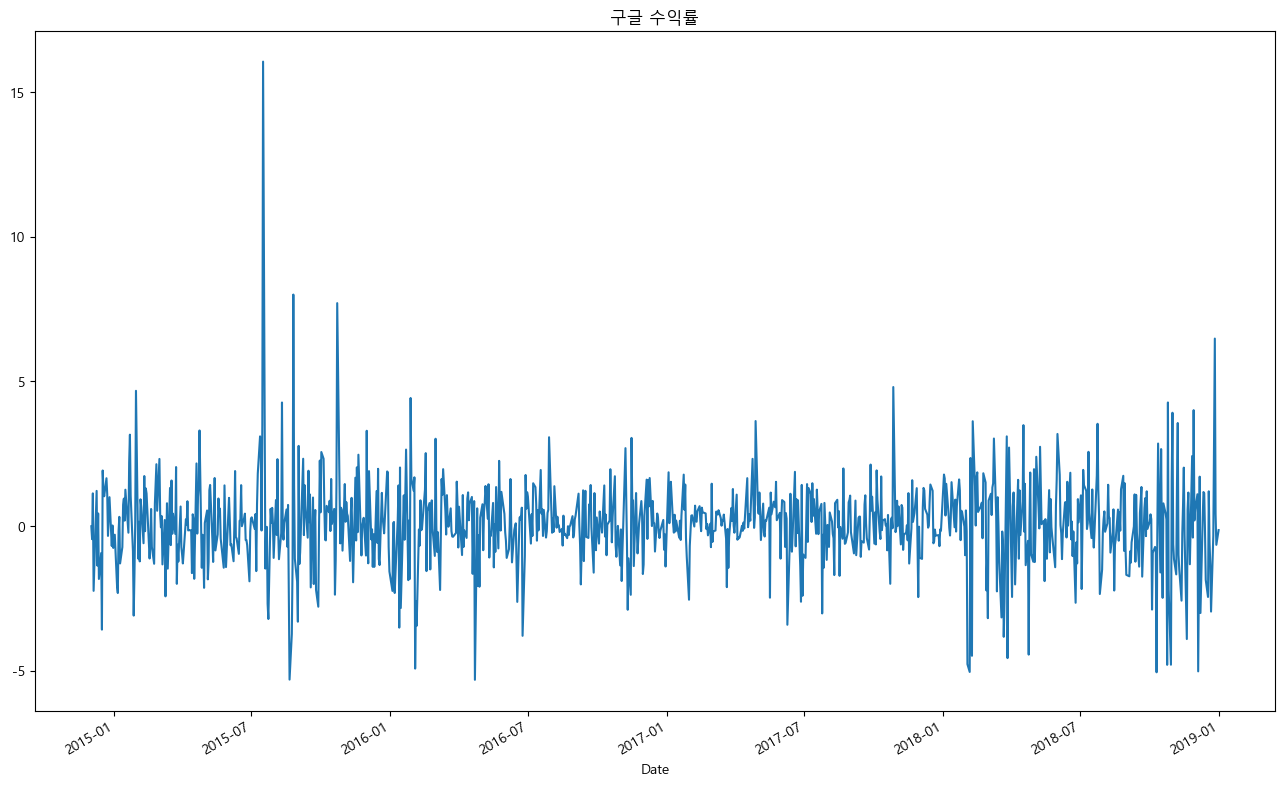

In [18]:
goog_df = pd.read_csv(f"{FILE_PATH}/{RISKY_ASSET}.csv", encoding="utf-8")
goog_df['Date'] = pd.to_datetime(goog_df['Date']) # 날짜로 변환
goog_df = goog_df.set_index('Date')               # Date를 인덱스로 설정
goog_df = goog_df.loc[START_DATE:END_DATE]        # 분석 기간

returns= goog_df['adj_close'].pct_change().dropna() * 100 #단순수익률 백분율로 변환
returns.name = 'asset_returns'
returns.plot(title="구글 수익률", figsize=(16,10))

### ARCH(1) 모델 적용
ARCH : 과거 충격(오차의 제곱)이 현재 변동성에 미치는 영향 분석

비대칭항 : 과거 충격의 방향(양/음)에 따라 현재 변동성에 미치는 영향이 달라지는지 분석

GARCH : 과거 충격(오차의 제곱)뿐만 아니라 과거의 조건부 변동성 자체가 현재 변동성에 미치는 영향까지 고려

In [20]:
#ARCH(1) 모델임으로 ARCH항(p) 개수는 1, 비대칭항(o), GARCH항(q)  개수는 0으로 설정
model = arch_model(returns, mean='Zero', vol='ARCH', p=1, o=0, q=0)
model_fitted = model.fit(disp='off')
print(model_fitted.summary())

                        Zero Mean - ARCH Model Results                        
Dep. Variable:          asset_returns   R-squared:                       0.000
Mean Model:                 Zero Mean   Adj. R-squared:                  0.001
Vol Model:                       ARCH   Log-Likelihood:               -1838.53
Distribution:                  Normal   AIC:                           3681.07
Method:            Maximum Likelihood   BIC:                           3690.94
                                        No. Observations:                 1027
Date:                Sat, Sep 19 2026   Df Residuals:                     1027
Time:                        22:18:04   Df Model:                            0
                             Volatility Model                             
                 coef    std err          t      P>|t|    95.0% Conf. Int.
--------------------------------------------------------------------------
omega          1.6313      0.165      9.879  5.133e-23   [  1.30

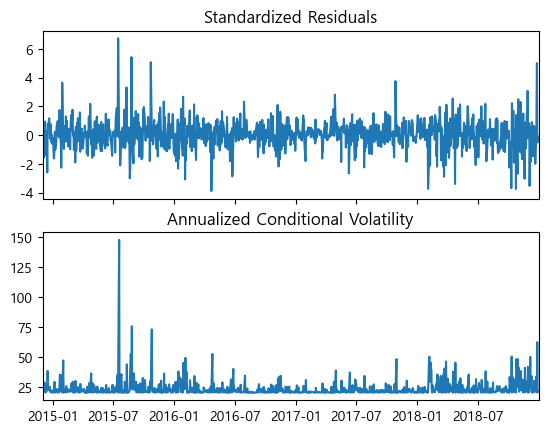

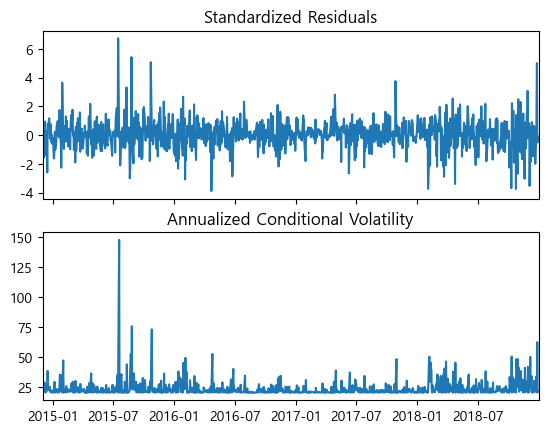

In [29]:
model_fitted.plot(annualize='D')

### GARCH(1,1) 모델 적용

In [30]:
model = arch_model(returns, mean='Zero', vol='GARCH', p=1, o=0, q=1)
model_fitted = model.fit(disp='off')
print(model_fitted.summary())

                       Zero Mean - GARCH Model Results                        
Dep. Variable:          asset_returns   R-squared:                       0.000
Mean Model:                 Zero Mean   Adj. R-squared:                  0.001
Vol Model:                      GARCH   Log-Likelihood:               -1803.91
Distribution:                  Normal   AIC:                           3613.83
Method:            Maximum Likelihood   BIC:                           3628.63
                                        No. Observations:                 1027
Date:                Sat, Sep 19 2026   Df Residuals:                     1027
Time:                        22:55:39   Df Model:                            0
                              Volatility Model                             
                 coef    std err          t      P>|t|     95.0% Conf. Int.
---------------------------------------------------------------------------
omega          0.1833      0.167      1.097      0.273    [ -

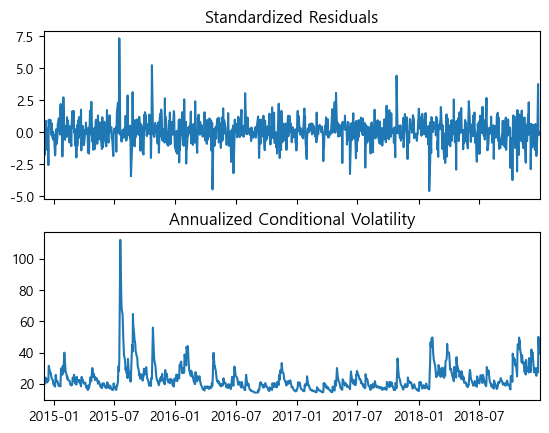

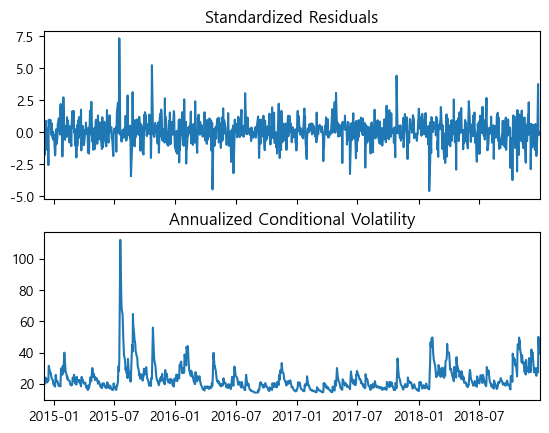

In [31]:
model_fitted.plot(annualize='D')